In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("21-housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

<Axes: >

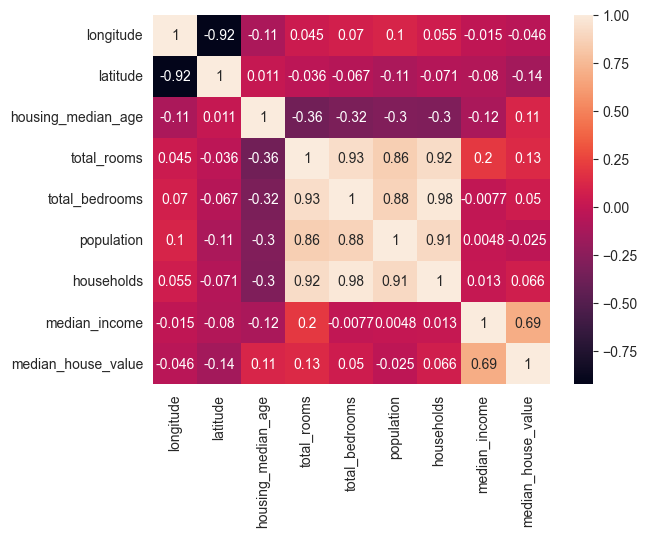

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
#outlier bulma fonksiyonu
def find_outliers_iqr(df, threshold):
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    print(numeric_cols)
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3 - Q1

        lower_bound = Q1 - threshold * iqr
        upper_bound = Q3 + threshold * iqr

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        }
    return pd.DataFrame(outlier_summary)

find_outliers_iqr(df, threshold=1.5)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.00000
outlier_percentage,0.000,0.00,0.0,0.062355,0.061579,0.057946,0.059109,0.032994,0.05189
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.50000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.50000


In [12]:
#tüm kolonlardaki outlier dataları silme
def remove_outliers_from_all_column(df,threshold=1.5):
    df_clean = df.copy()
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3 - Q1

        lower_bound = Q1 - threshold * iqr
        upper_bound = Q3 + threshold * iqr

        df_clean =  df_clean[ (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean.copy()

df_all_clean = remove_outliers_from_all_column(df)
print("all target column cleaning shape: ",df_all_clean.shape)

all target column cleaning shape:  (17446, 10)


In [13]:
df_all_clean.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

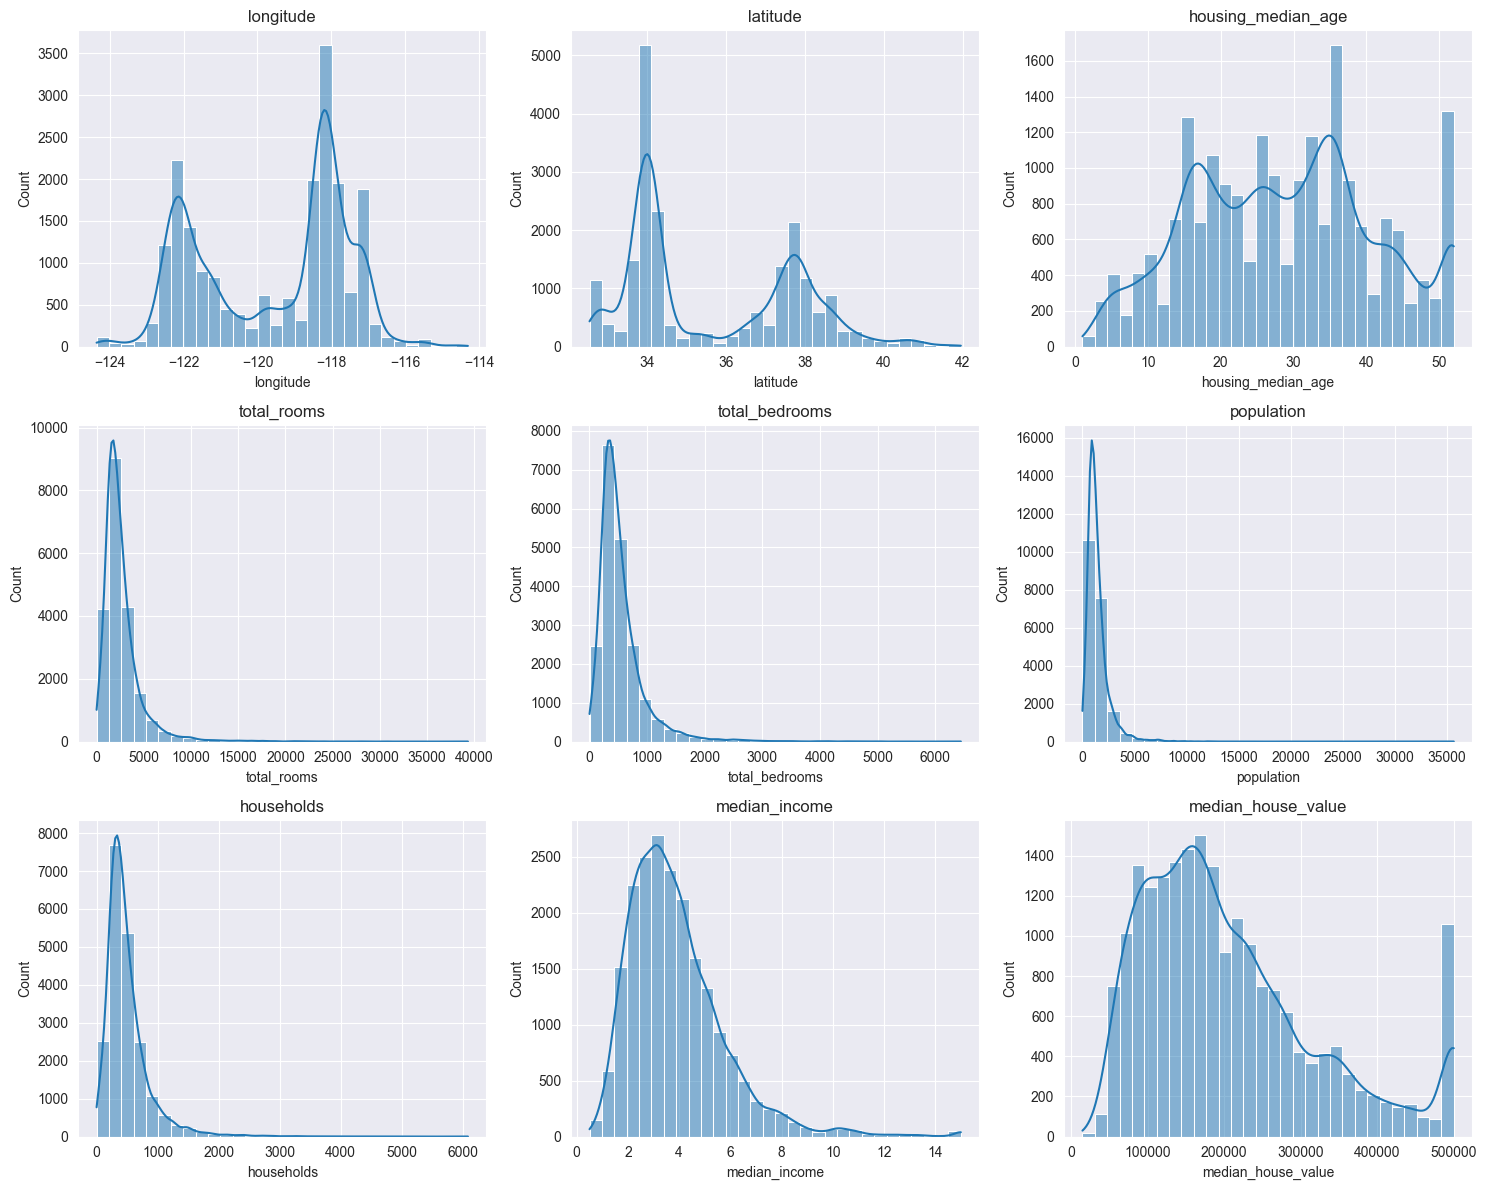

In [14]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df)

In [15]:
df_clean = pd.get_dummies(df,columns=['ocean_proximity'], drop_first=True)

In [16]:
df_clean = df_clean.dropna(subset=['total_bedrooms'])

In [17]:
X = df_clean.drop("median_house_value", axis=1)
y = df_clean["median_house_value"]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [19]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(true,predicted):
    r2 = r2_score(true,predicted)
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    return r2,mae,mse,rmse

models = {
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "AdaBoost":AdaBoostRegressor(),
    "Gradient Boosting":GradientBoostingRegressor(),
    "xgboost":XGBRegressor()
}

for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_r2, model_train_mae, model_train_mse, model_train_rmse = evaluate_model(y_train,y_train_pred)
    model_test_r2, model_test_mae, model_test_mse, model_test_rmse = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model Performance for Training Set")
    print("Root Mean Squared Error: ",model_train_rmse)
    print("Mean Absolute Error: ",model_train_mae)
    print("R2 Score: ",model_train_r2)
    print("Mean Squared Error : ",model_train_mse)

    print("-------------------------------------")

    print("Model Performance for Test Set")
    print("Root Mean Squared Error: ",model_test_rmse)
    print("Mean Absolute Error: ",model_test_mae)
    print("R2 Score: ",model_test_r2)
    print("Mean Squared Error : ",model_test_mse)

    print("-------------------------------------")
    print("\n")

Linear Regression
Model Performance for Training Set
Root Mean Squared Error:  68209.39158631829
Mean Absolute Error:  49426.81044279184
R2 Score:  0.6475680250963837
Mean Squared Error :  4652521100.575709
-------------------------------------
Model Performance for Test Set
Root Mean Squared Error:  69642.68811690755
Mean Absolute Error:  50223.04463127733
R2 Score:  0.6435297098378012
Mean Squared Error :  4850104008.148855
-------------------------------------


Lasso
Model Performance for Training Set
Root Mean Squared Error:  68209.41803489126
Mean Absolute Error:  49427.13506163188
R2 Score:  0.6475677517813931
Mean Squared Error :  4652524708.658549
-------------------------------------
Model Performance for Test Set
Root Mean Squared Error:  69643.31522193897
Mean Absolute Error:  50223.849419449114
R2 Score:  0.6435232900592136
Mean Squared Error :  4850191355.102357
-------------------------------------


Ridge
Model Performance for Training Set
Root Mean Squared Error:  6821

In [37]:
from sklearn.preprocessing import PowerTransformer
pt_X = PowerTransformer()

In [38]:
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [39]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [40]:
column_name = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=column_name)

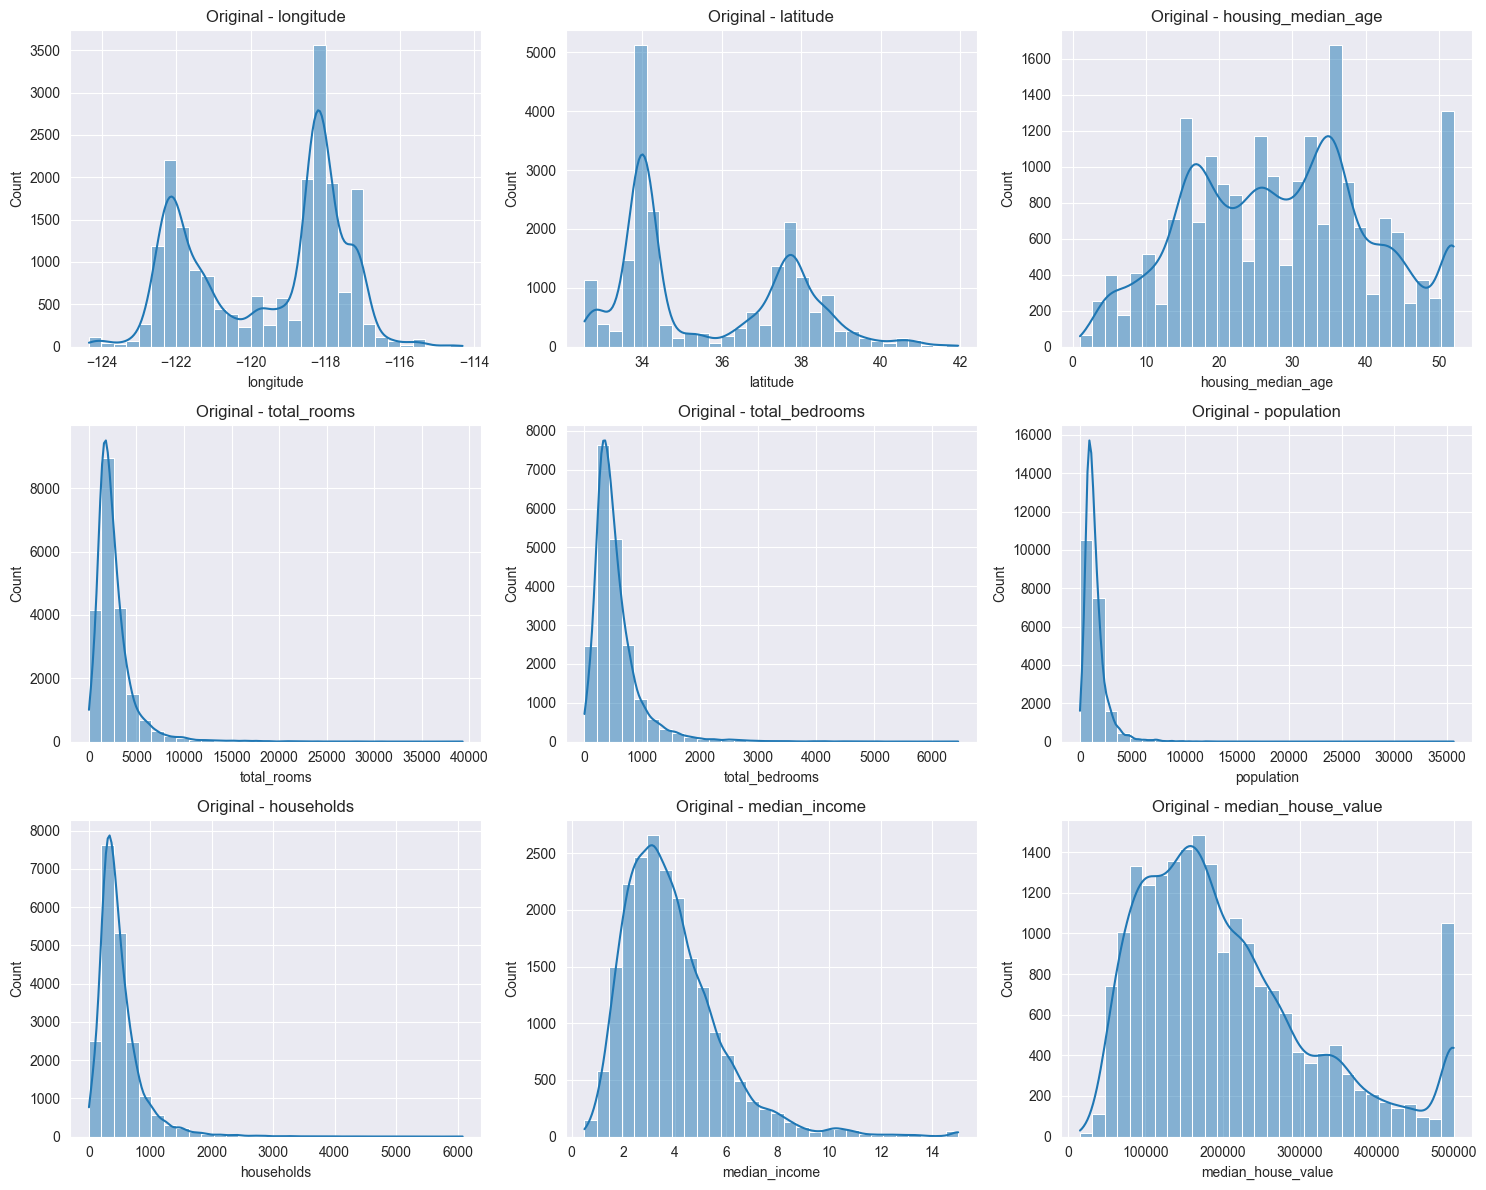

In [44]:
plot_all_histograms(df_clean,title_prefix="Original - ")

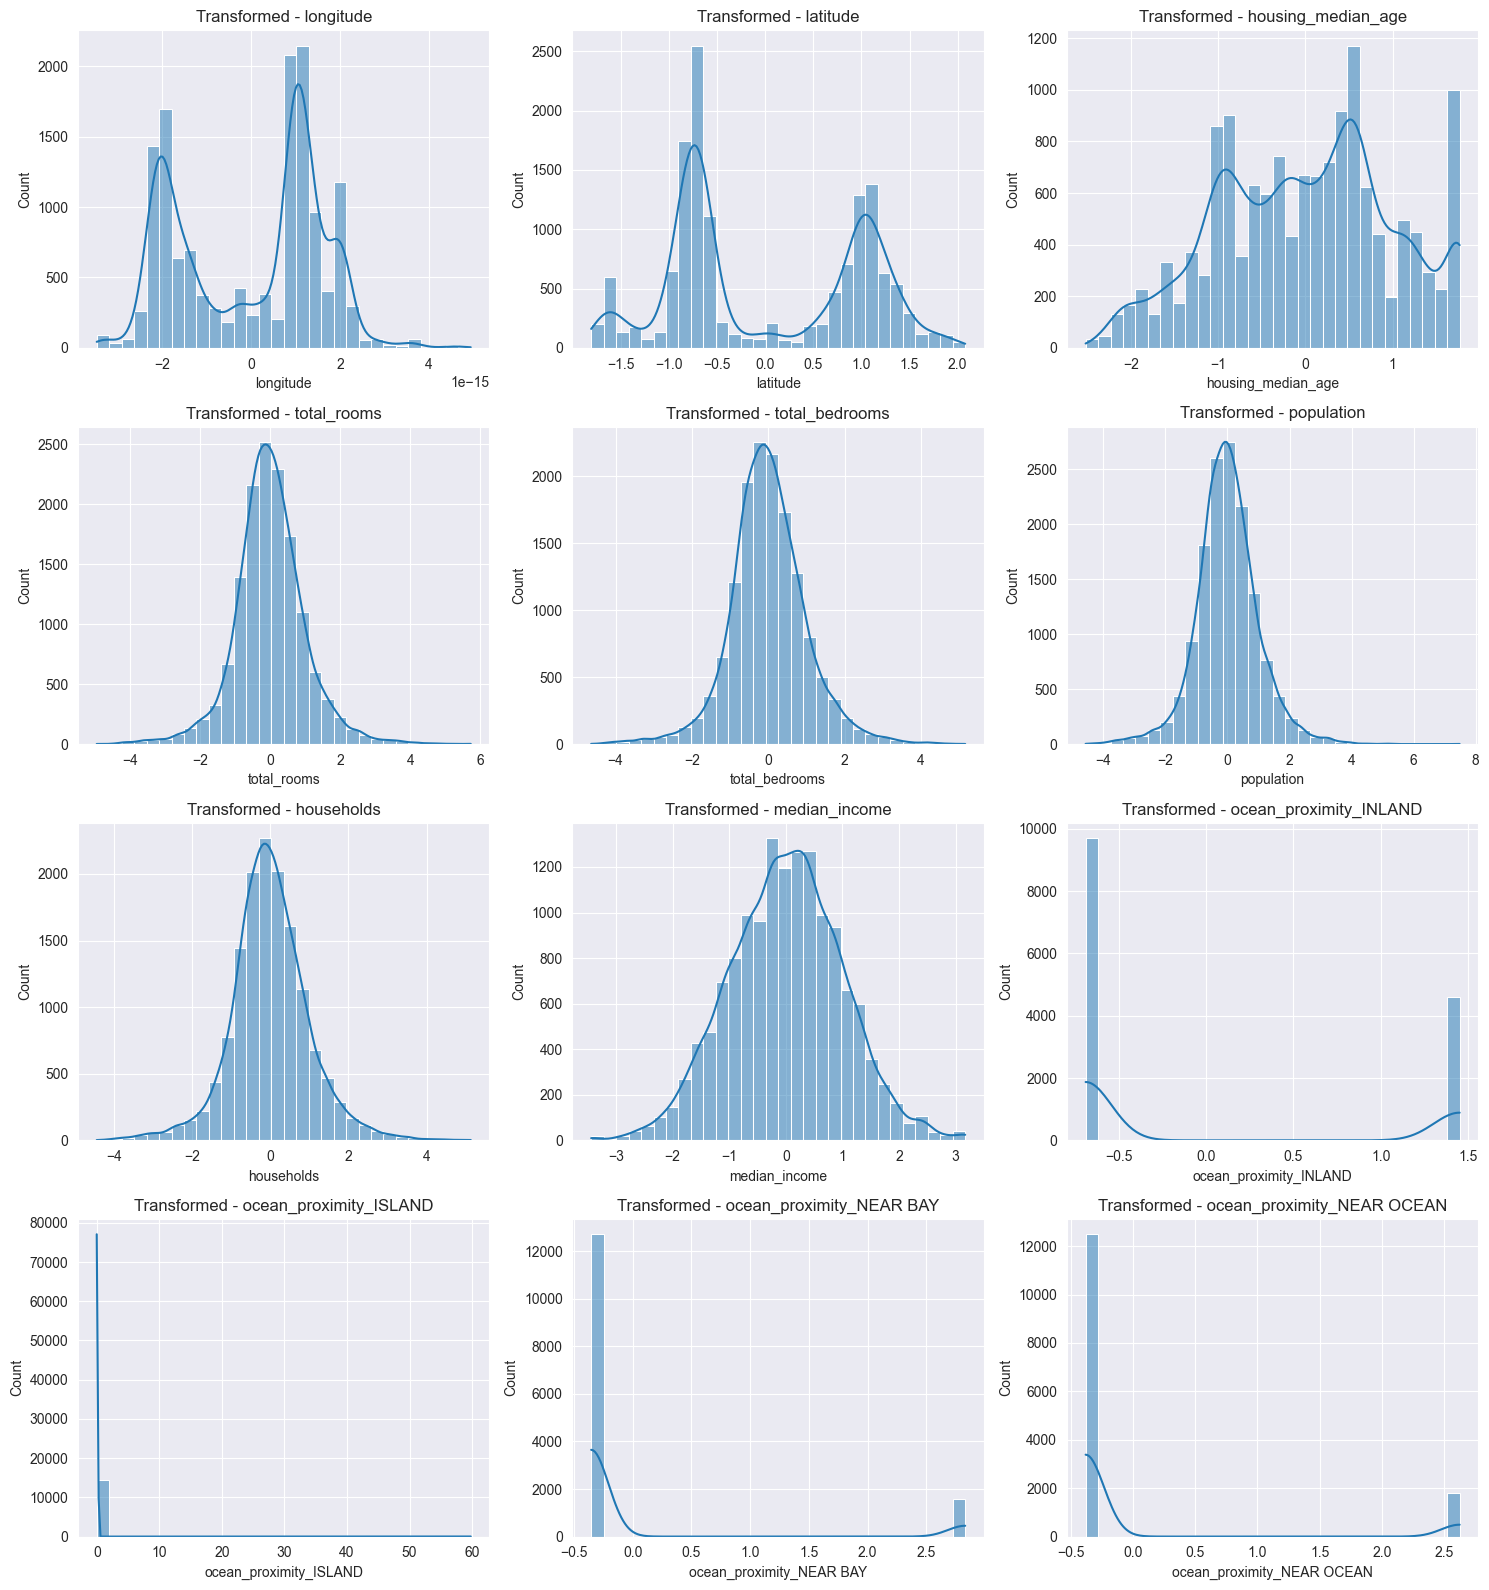

In [42]:
plot_all_histograms(X_train_transformed_df,title_prefix="Transformed - ")

In [47]:
from scipy.stats import boxcox

y_train_transformed,lambda_y = boxcox(y_train)

def inverse_boxcox(y,lambda_):
    if lambda_ ==0 :
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1/ lambda_)

In [60]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_train_transformed, y_train_transformed)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
column_name = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=column_name)

In [62]:
y_pred_transformed = model2.predict(X_test_transformed)

In [63]:
y_pred_original = inverse_boxcox(y_pred_transformed,lambda_y)

In [64]:
from sklearn.metrics import r2_score,mean_squared_error
print("R2 score",r2_score(y_test,y_pred_original))
print("Mean squared error",mean_squared_error(y_test,y_pred_original))

R2 score 0.6497467229236665
Mean squared error 4765515864.568224


In [ ]:
# transform denendi ama kayda değer bir sonuç bulunamadı.